In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. LOAD DATA
# ==========================================
# Creating the dataframe from your provided CSV data
df = pd.read_csv('Student.csv')

print("Dataset Shape:", df.shape)
print(df.head())

# 2. EXPLORATORY DATA ANALYSIS (EDA) (5 Marks)
# ==========================================
print("\n--- Summary Statistics ---")
print(df.describe())

print("\n--- Missing Values ---")
print(df.isnull().sum())


Dataset Shape: (1000, 8)
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  

--- Summary Statistics ---
       math score  reading score  writing score
count  1000.00000    1000.000000    1000.000000
mean     6

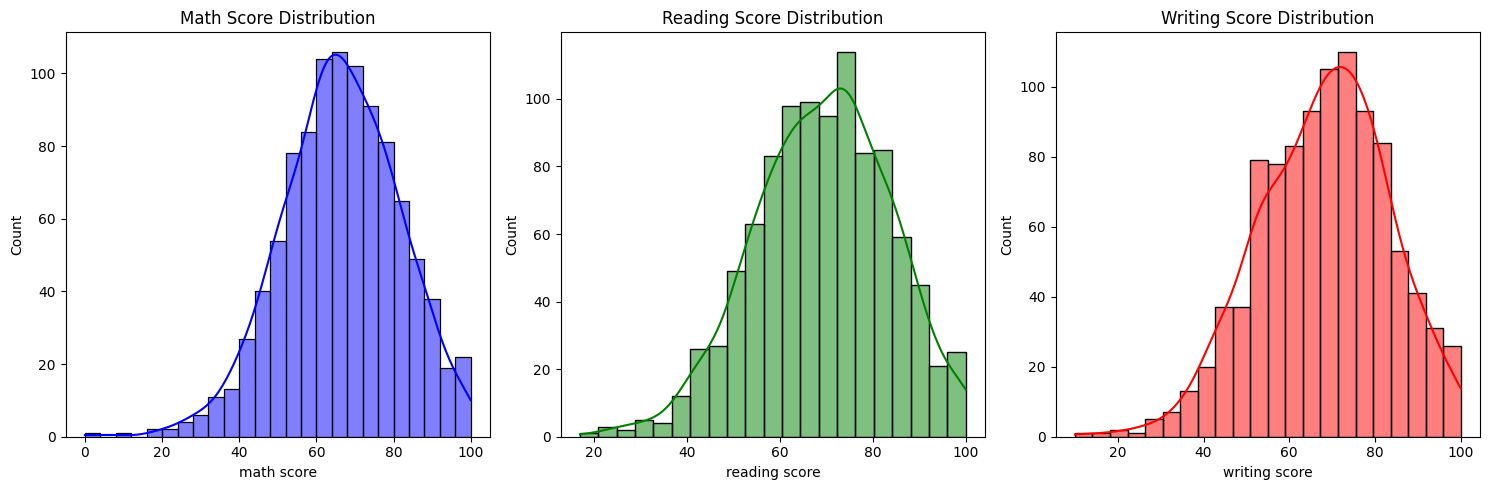

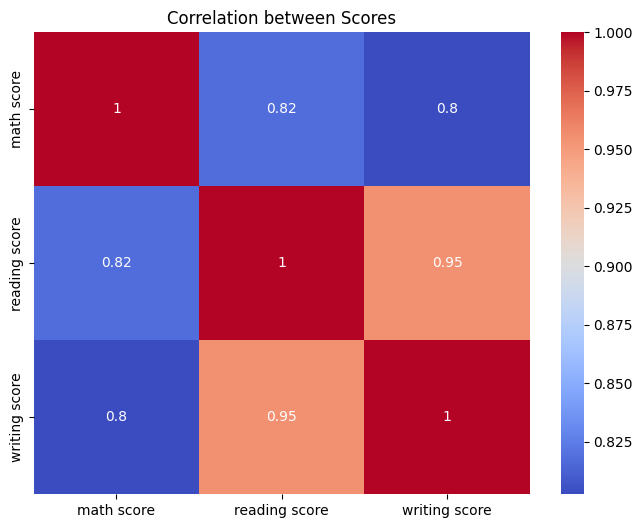

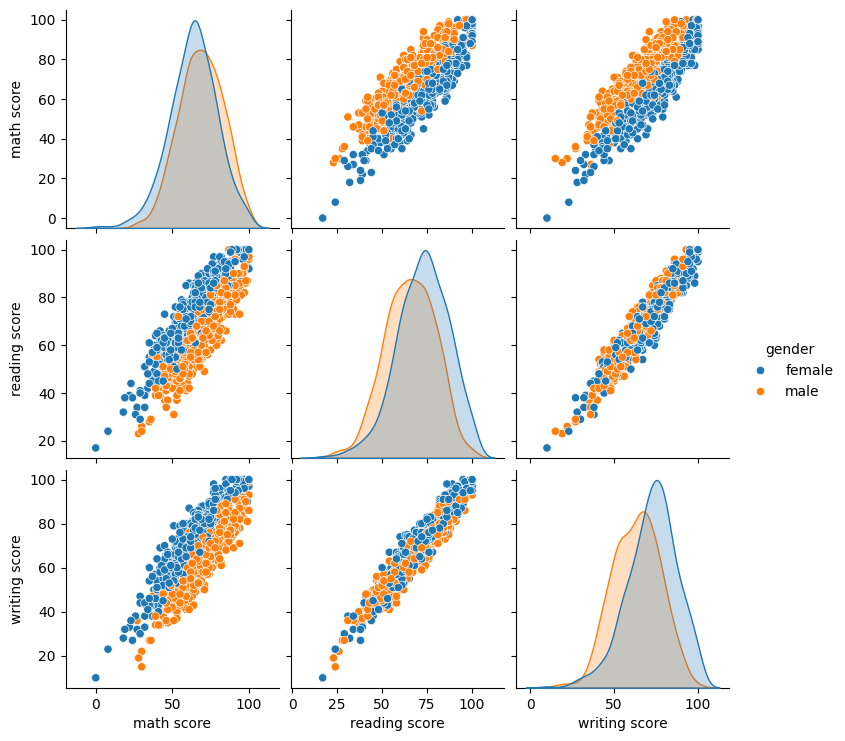

In [2]:
# Visualization 1: Distributions of Scores
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['math score'], kde=True, color='blue')
plt.title('Math Score Distribution')

plt.subplot(1, 3, 2)
sns.histplot(df['reading score'], kde=True, color='green')
plt.title('Reading Score Distribution')

plt.subplot(1, 3, 3)
sns.histplot(df['writing score'], kde=True, color='red')
plt.title('Writing Score Distribution')
plt.tight_layout()
plt.show()

# Visualization 2: Correlation Heatmap
# We need to see if the scores are related
plt.figure(figsize=(8, 6))
sns.heatmap(df[['math score', 'reading score', 'writing score']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation between Scores')
plt.show()

# Visualization 3: Pairplot with categorical hue (e.g., Gender)
sns.pairplot(df, hue='gender', vars=['math score', 'reading score', 'writing score'])
plt.show()



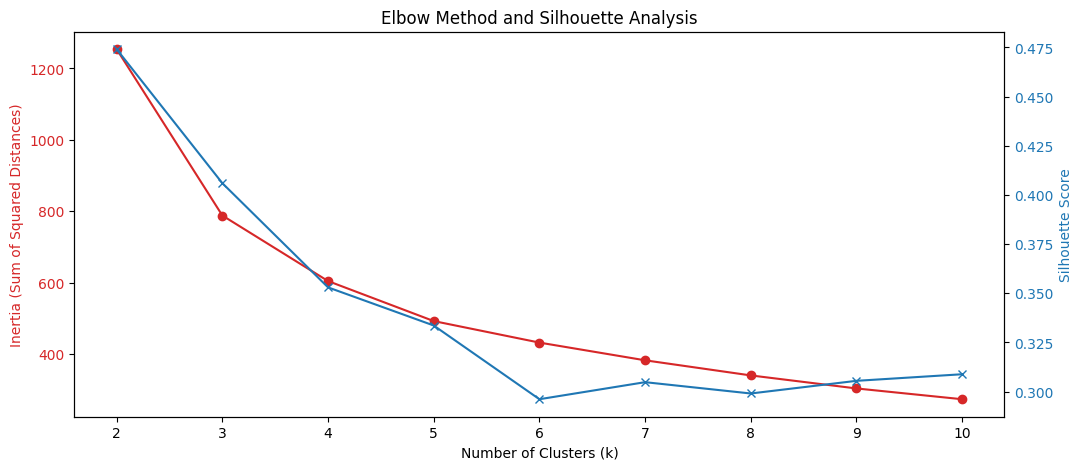

In [3]:
# 3. DATA PRE-PROCESSING & CLUSTERING ANALYSIS (10 Marks)
# ==========================================

# Feature Selection:
# KMeans works best on numerical data. We will cluster students based on their 
# performance (math, reading, writing).
X = df[['math score', 'reading score', 'writing score']]

# Scaling:
# Always scale data for KMeans so one variable doesn't dominate (though these are all 0-100, it's best practice).
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determining Optimal Clusters (The Elbow Method)
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow Curve and Silhouette Scores
fig, ax1 = plt.subplots(figsize=(12, 5))

color = 'tab:red'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Sum of Squared Distances)', color=color)
ax1.plot(K_range, inertia, marker='o', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(K_range, silhouette_scores, marker='x', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Elbow Method and Silhouette Analysis')
plt.show()



In [11]:
# 4. IMPLEMENTING THE FINAL MODEL
# ==========================================
# Based on the plots, let's pick k=3 (likely identifying Low, Medium, High performers)
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)

# Add cluster labels back to original dataframe
df['Cluster'] = clusters

# Evaluate Final Model
score = silhouette_score(X_scaled, clusters)
print(f"Silhouette Score for k={optimal_k}: {score:.4f}")



Silhouette Score for k=3: 0.4060


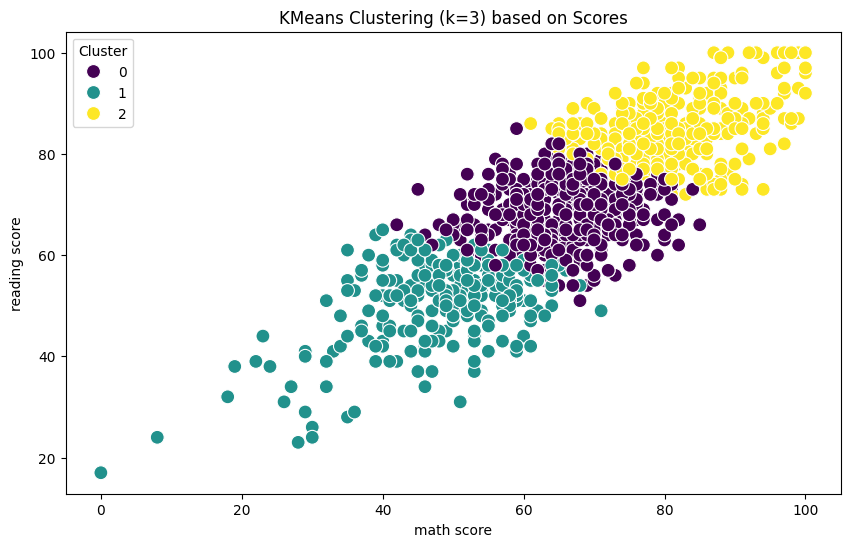


--- Cluster Means (Numerical) ---
         math score  reading score  writing score
Cluster                                          
0         65.338600      68.458239      67.821670
1         48.096386      50.670683      48.485944
2         81.714286      85.146104      84.207792

--- Test Prep Course Distribution per Cluster ---
test preparation course  completed      none
Cluster                                     
0                         0.347630  0.652370
1                         0.204819  0.795181
2                         0.496753  0.503247


In [5]:
# 5. CLUSTER INTERPRETATION & VISUALIZATION
# ==========================================

# Visualizing Clusters (Math vs Reading)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='math score', y='reading score', hue='Cluster', palette='viridis', s=100)
plt.title(f'KMeans Clustering (k={optimal_k}) based on Scores')
plt.show()

# Analyze the characteristics of each cluster
print("\n--- Cluster Means (Numerical) ---")
print(df.groupby('Cluster')[['math score', 'reading score', 'writing score']].mean())

# Analyze Categorical breakdown per cluster (Example: Test Prep Course)
print("\n--- Test Prep Course Distribution per Cluster ---")
print(pd.crosstab(df['Cluster'], df['test preparation course'], normalize='index'))